In [5]:
#Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [8]:
# Load Dataset
df = pd.read_csv(r"C:\Users\MD SAHIL RAZA\OneDrive\Desktop\Downloads\archive (2).zip")
df

,job_id,job_title,company_name,location,experience_required_years,skills,salary_min_inr,salary_max_inr,employment_type,remote_option
0,1,Data Analyst,Flipkart,Noida,3,"Kubernetes, Docker, Tableau",735003,1098465,Internship,Hybrid
1,2,ML Engineer,Infosys,Kolkata,3,"Python, React, Tableau",905315,1047637,Internship,Hybrid
2,3,ML Engineer,Cognizant,Hyderabad,11,"Node.js, Machine Learning, SQL",1733025,1964890,Internship,Remote
3,4,Backend Developer,Flipkart,Chennai,4,"Python, Machine Learning, React",801572,1141406,Contract,Hybrid
4,5,Data Analyst,Cognizant,Kolkata,15,"Power BI, Docker, Azure",818144,1208834,Contract,Remote
...,...,...,...,...,...,...,...,...,...,...
9995,9996,DevOps Engineer,TCS,Chennai,8,"SQL, Node.js, Azure",1040221,1158068,Internship,Hybrid
9996,9997,Frontend Developer,Wipro,Chennai,3,"Node.js, Kubernetes, Java",973031,1334088,Contract,Hybrid
9997,9998,Backend Developer,Wipro,Kolkata,10,"Tableau, Docker, Java",1131348,1404597,Internship,Remote
9998,9999,Cybersecurity Analyst,Wipro,Bangalore,10,"Node.js, AWS, Power BI",995417,1391367,Full-time,Remote


In [9]:
# To see the 1st five records of df
df.head()

,job_id,job_title,company_name,location,experience_required_years,skills,salary_min_inr,salary_max_inr,employment_type,remote_option
0,1,Data Analyst,Flipkart,Noida,3,"Kubernetes, Docker, Tableau",735003,1098465,Internship,Hybrid
1,2,ML Engineer,Infosys,Kolkata,3,"Python, React, Tableau",905315,1047637,Internship,Hybrid
2,3,ML Engineer,Cognizant,Hyderabad,11,"Node.js, Machine Learning, SQL",1733025,1964890,Internship,Remote
3,4,Backend Developer,Flipkart,Chennai,4,"Python, Machine Learning, React",801572,1141406,Contract,Hybrid
4,5,Data Analyst,Cognizant,Kolkata,15,"Power BI, Docker, Azure",818144,1208834,Contract,Remote


In [11]:
# informations of df
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   job_id                     10000 non-null  int64 
 1   job_title                  10000 non-null  object
 2   company_name               10000 non-null  object
 3   location                   10000 non-null  object
 4   experience_required_years  10000 non-null  int64 
 5   skills                     10000 non-null  object
 6   salary_min_inr             10000 non-null  int64 
 7   salary_max_inr             10000 non-null  int64 
 8   employment_type            10000 non-null  object
 9   remote_option              10000 non-null  object
dtypes: int64(4), object(6)
memory usage: 781.4+ KB


In [22]:
df.columns

Index(['job_id', 'job_title', 'company_name', 'location',
       'experience_required_years', 'skills', 'salary_min_inr',
       'salary_max_inr', 'employment_type', 'remote_option'],
      dtype='object')

In [23]:
df.describe()

,job_id,experience_required_years,salary_min_inr,salary_max_inr
count,10000.00000,10000.000000,1.000000e+04,1.000000e+04
mean,5000.50000,7.489300,1.146712e+06,1.395675e+06
std,2886.89568,4.596346,4.310013e+05,4.415012e+05
min,1.00000,0.000000,4.002240e+05,5.179770e+05
25%,2500.75000,4.000000,8.213712e+05,1.058016e+06
50%,5000.50000,7.000000,1.082927e+06,1.337484e+06
75%,7500.25000,11.000000,1.429934e+06,1.680679e+06
max,10000.00000,15.000000,2.399534e+06,2.790285e+06


In [24]:
#Handles missing data
df.isnull().sum()

job_id                       0
job_title                    0
company_name                 0
location                     0
experience_required_years    0
skills                       0
salary_min_inr               0
salary_max_inr               0
employment_type              0
remote_option                0
dtype: int64

Data Cleaning

In [25]:
# Remove duplicates
df.drop_duplicates(inplace=True)

In [26]:
# Remove unwanted column if exists
if "Unnamed: 0" in df.columns:
    df.drop(columns=["Unnamed: 0"], inplace=True)


Exploratory Data Analysis (EDA)

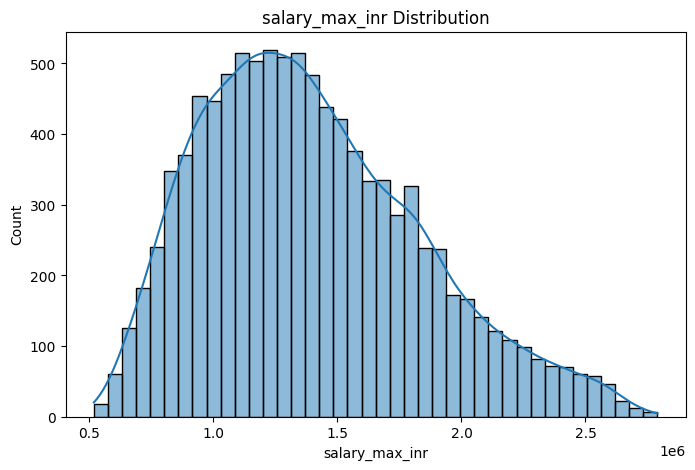

In [30]:
# Salary Distribution
plt.figure(figsize=(8,5))
sns.histplot(df["salary_max_inr"], kde=True)
plt.title("salary_max_inr Distribution")
plt.show()

In [35]:
# If Experience column exists
if "experience" in df.columns:
    plt.figure(figsize=(8,5))
    sns.scatterplot(x=df["experience"], y=df["salary"])
    plt.title("Experience vs Salary")
    plt.show()

Feature Selection

In [37]:
# Target variable
y = df["salary_max_inr"]

In [39]:
# Input features
X = df.drop("salary_max_inr", axis=1)


In [40]:
# Encode Categorical Variables
X = pd.get_dummies(X, drop_first=True)

In [41]:
# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [42]:

#Train Linear Regression Model
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [45]:
#Salary Prediction
y_pred = model.predict(X_test)
print("\nPredicted Salary Values:")
print(y_pred[:10])


Predicted Salary Values:
[2492200.02655974  903090.11900356  848712.54255374  853069.81435365
 1520920.35688242 1406532.4808229  1798159.40748016 1073188.17429622
 2057645.57603124 1852178.51470412]


Model Evaluation

In [46]:

# Model Evaluation

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\nModel Evaluation")
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)


Model Evaluation
MAE: 83499.65532275954
MSE: 9684821522.643812
RMSE: 98411.4908059207
R2 Score: 0.9504273683070933
